**Data Collection**

In [ ]:
# Step 1: Import required libraries
# yfinance is used to fetch stock data
# pandas is used for handling data in table format
import yfinance as yf
import pandas as pd

In [ ]:
# Step 2: Define the stock ticker and the time period
ticker = "RELIANCE.NS"
start_date = "2018-01-01"
end_date = "2024-01-01"

In [ ]:
# Download historical stock data from Yahoo Finance
# RELIANCE.NS represents Reliance Industries (NSE)
data = yf.download("RELIANCE.NS", start="2018-01-01", end="2024-01-01")

# Display first few rows to understand structure
print("Data Preview:")
print(data.head())

# Check number of rows and columns
print("Data Shape:")
print(data.shape)

/tmp/ipykernel_284/561725367.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("RELIANCE.NS", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Data Preview:
Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2018-01-01  401.864807  407.585208  400.870911  407.585208     9453202
2018-01-02  402.483215  406.193768  400.384994  403.300424     9499419
2018-01-03  404.095551  409.042944  403.322514  408.601196    13507800
2018-01-04  406.525055  407.187662  404.493091  405.575331     9008932
2018-01-05  407.828156  409.440487  406.502971  407.187664     7441284
Data Shape:
(1481, 5)


In [ ]:
# Step 6: Check dataset information
# This shows column names, data types, and missing values
print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1481 entries, 2018-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   1481 non-null   float64
 1   (High, RELIANCE.NS)    1481 non-null   float64
 2   (Low, RELIANCE.NS)     1481 non-null   float64
 3   (Open, RELIANCE.NS)    1481 non-null   float64
 4   (Volume, RELIANCE.NS)  1481 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 69.4 KB
None


In [ ]:
# Step 7: Save the dataset to a CSV file
# This allows us to reuse the data without downloading again
data.to_csv("stock_data.csv")


In [ ]:
# Step 8: Confirm successful data collection
print("Data collection completed successfully.")

Data collection completed successfully.


**Data Preprocessing**

In [ ]:
# Remove missing values (if any exist in raw data)
data = data.dropna()

# Sort data by date to maintain time-series order
data = data.sort_index()

# Verify dataset after cleaning
print("After Preprocessing:")
print(data.shape)

# Check for missing values in each column
print("Missing Values:")
print(data.isnull().sum())

After Preprocessing:
(1481, 5)
Missing Values:
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64


**Feature Engineering**

Daily Return

In [ ]:
# Calculate daily percentage return based on closing price
# This represents daily market movement
data['Return'] = data['Close'].pct_change()

# Display new feature
print("Return Feature:")
print(data[['Close', 'Return']].head())

Return Feature:
Price            Close    Return
Ticker     RELIANCE.NS          
Date                            
2018-01-01  401.864807       NaN
2018-01-02  402.483215  0.001539
2018-01-03  404.095551  0.004006
2018-01-04  406.525055  0.006012
2018-01-05  407.828156  0.003205


Rolling Mean

In [ ]:
# Calculate 10-day rolling mean of returns
# Captures short-term trend in the market
data['Rolling_Mean'] = data['Return'].rolling(window=10).mean()

# Display rolling mean values
print("Rolling Mean Feature:")
print(data[['Return', 'Rolling_Mean']].head(15))

Rolling Mean Feature:
Price         Return Rolling_Mean
Ticker                           
Date                             
2018-01-01       NaN          NaN
2018-01-02  0.001539          NaN
2018-01-03  0.004006          NaN
2018-01-04  0.006012          NaN
2018-01-05  0.003205          NaN
2018-01-08  0.005741          NaN
2018-01-09  0.013354          NaN
2018-01-10  0.001488          NaN
2018-01-11 -0.004881          NaN
2018-01-12  0.011997          NaN
2018-01-15  0.000158     0.004262
2018-01-16 -0.027604     0.001348
2018-01-17  0.001679     0.001115
2018-01-18 -0.005192    -0.000005
2018-01-19  0.012613     0.000935


Rolling Standard Deviation (Volatility)

In [ ]:
# Calculate 10-day rolling standard deviation
# Measures volatility (risk level)
data['Rolling_Std'] = data['Return'].rolling(window=10).std()

# Display volatility values
print("Rolling Std Feature:")
print(data[['Return', 'Rolling_Std']].head(15))

Rolling Std Feature:
Price         Return Rolling_Std
Ticker                          
Date                            
2018-01-01       NaN         NaN
2018-01-02  0.001539         NaN
2018-01-03  0.004006         NaN
2018-01-04  0.006012         NaN
2018-01-05  0.003205         NaN
2018-01-08  0.005741         NaN
2018-01-09  0.013354         NaN
2018-01-10  0.001488         NaN
2018-01-11 -0.004881         NaN
2018-01-12  0.011997         NaN
2018-01-15  0.000158    0.005421
2018-01-16 -0.027604    0.011487
2018-01-17  0.001679    0.011451
2018-01-18 -0.005192    0.011466
2018-01-19  0.012613    0.012126


Z-score Calculation

In [ ]:
# Standardize returns using Z-score
# Shows how far current return deviates from normal behavior
data['Z_score'] = (data['Return'] - data['Rolling_Mean']) / data['Rolling_Std']

# Display Z-score values
print("Z-score Feature:")
print(data[['Return', 'Z_score']].head(15))

Z-score Feature:
Price         Return   Z_score
Ticker                        
Date                          
2018-01-01       NaN       NaN
2018-01-02  0.001539       NaN
2018-01-03  0.004006       NaN
2018-01-04  0.006012       NaN
2018-01-05  0.003205       NaN
2018-01-08  0.005741       NaN
2018-01-09  0.013354       NaN
2018-01-10  0.001488       NaN
2018-01-11 -0.004881       NaN
2018-01-12  0.011997       NaN
2018-01-15  0.000158 -0.757043
2018-01-16 -0.027604 -2.520366
2018-01-17  0.001679  0.049302
2018-01-18 -0.005192 -0.452337
2018-01-19  0.012613  0.963026


Step 5: Target Variable (Shock Detection)


In [ ]:
# Define threshold for identifying abnormal movements
threshold = 2

# Create binary target variable
# 1 indicates market shock, 0 indicates normal condition
data['Shock'] = (data['Z_score'].abs() > threshold).astype(int)

# Display shock classification
print("Shock Variable:")
print(data[['Z_score', 'Shock']].head(15))

Shock Variable:
Price        Z_score Shock
Ticker                    
Date                      
2018-01-01       NaN     0
2018-01-02       NaN     0
2018-01-03       NaN     0
2018-01-04       NaN     0
2018-01-05       NaN     0
2018-01-08       NaN     0
2018-01-09       NaN     0
2018-01-10       NaN     0
2018-01-11       NaN     0
2018-01-12       NaN     0
2018-01-15 -0.757043     0
2018-01-16 -2.520366     1
2018-01-17  0.049302     0
2018-01-18 -0.452337     0
2018-01-19  0.963026     0


Step 6: Final Cleaning

In [ ]:
# Remove rows with NaN values created due to rolling calculations
data = data.dropna()

# Check final dataset size
print("Final Data Shape:")
print(data.shape)

# Preview cleaned dataset
print("Final Data Preview:")
print(data.head())

Final Data Shape:
(1471, 10)
Final Data Preview:
Price            Close        High         Low        Open      Volume  \
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS   
Date                                                                     
2018-01-15  419.268982  423.399167  417.524165  419.644472    11120925   
2018-01-16  407.695618  418.628473  406.392519  418.628473    10825151   
2018-01-17  408.380341  410.368133  400.650032  409.042948    13204016   
2018-01-18  406.259979  410.633109  404.228016  410.368078     9381821   
2018-01-19  411.384094  412.753451  407.320167  407.717713     9973533   

Price         Return Rolling_Mean Rolling_Std   Z_score Shock  
Ticker                                                         
Date                                                           
2018-01-15  0.000158     0.004262    0.005421 -0.757043     0  
2018-01-16 -0.027604     0.001348    0.011487 -2.520366     1  
2018-01-17  0.001679     0.001115    0

Step 7: Dataset Summary

In [ ]:
# Display dataset structure and data types
print("Dataset Info:")
print(data.info())

# Display statistical summary
print("Summary Statistics:")
print(data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1471 entries, 2018-01-15 to 2023-12-29
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   1471 non-null   float64
 1   (High, RELIANCE.NS)    1471 non-null   float64
 2   (Low, RELIANCE.NS)     1471 non-null   float64
 3   (Open, RELIANCE.NS)    1471 non-null   float64
 4   (Volume, RELIANCE.NS)  1471 non-null   int64  
 5   (Return, )             1471 non-null   float64
 6   (Rolling_Mean, )       1471 non-null   float64
 7   (Rolling_Std, )        1471 non-null   float64
 8   (Z_score, )            1471 non-null   float64
 9   (Shock, )              1471 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 126.4 KB
None
Summary Statistics:
Price         Close         High          Low         Open        Volume  \
Ticker  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   RELIANCE.NS   
count   

STEP 6: MODEL BUILDING

In [ ]:
# Select input features (statistical indicators)
features = ['Return', 'Rolling_Mean', 'Rolling_Std']

X = data[features]

# Target variable (Shock: 1 = abnormal, 0 = normal)
y = data['Shock']

# Display sample data
print("Feature Data:")
print(X.head())

print("Target Data:")
print(y.head())

Feature Data:
Price         Return Rolling_Mean Rolling_Std
Ticker                                       
Date                                         
2018-01-15  0.000158     0.004262    0.005421
2018-01-16 -0.027604     0.001348    0.011487
2018-01-17  0.001679     0.001115    0.011451
2018-01-18 -0.005192    -0.000005    0.011466
2018-01-19  0.012613     0.000935    0.012126
Target Data:
Date
2018-01-15    0
2018-01-16    1
2018-01-17    0
2018-01-18    0
2018-01-19    0
Name: Shock, dtype: int64


6.2 Train-Test Split (Time-Series Based)

In [ ]:
# Split data based on time (no random shuffling)
# First 80% used for training, last 20% for testing
train_size = int(len(data) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Check dataset sizes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1176, 3)
Testing Data Shape: (295, 3)


6.3 Feature Scaling

In [ ]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Applied")

Feature Scaling Applied


6.4 Import and Train Logistic Regression

In [ ]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Initialize model with class balancing (important for imbalanced data)
model = LogisticRegression(class_weight='balanced')

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression Model Trained")

Logistic Regression Model Trained


6.5 Make Predictions

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Display first few predictions
print("Predictions:")
print(y_pred[:10])

Predictions:
[0 0 0 0 0 0 0 0 0 0]


6.6 Compare Actual vs Predicted

In [ ]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Display comparison
print("Actual vs Predicted:")
print(comparison.head(10))

Actual vs Predicted:
   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


6.7 Additional Model (Random Forest for Comparison)

In [ ]:
# Import Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier()

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred[:10])

Random Forest Predictions:
[0 0 0 0 0 0 0 0 0 0]


STEP 7: MODEL **EVALUATION**

7.1 Import Required Metrics

In [ ]:
# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score
import pandas as pd

7.2 Evaluate Logistic Regression

In [ ]:
# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix with labels for clarity
cm_df = pd.DataFrame(cm,
                     index=['Actual Normal', 'Actual Shock'],
                     columns=['Predicted Normal', 'Predicted Shock'])
print("Confusion Matrix (Logistic Regression):")
print(cm_df)

# Classification report (precision, recall, f1-score)
report = classification_report(y_test, y_pred)
print("\nClassification Report (Logistic Regression):")
print(report)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Logistic Regression):", round(accuracy, 4))

# Recall for shocks (class 1)
recall_shock = recall_score(y_test, y_pred)
print("Recall for Shock (class 1) (Logistic Regression):", round(recall_shock, 4))

Confusion Matrix (Logistic Regression):
               Predicted Normal  Predicted Shock
Actual Normal               262               24
Actual Shock                  6                3

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       286
           1       0.11      0.33      0.17         9

    accuracy                           0.90       295
   macro avg       0.54      0.62      0.56       295
weighted avg       0.95      0.90      0.92       295

Accuracy (Logistic Regression): 0.8983
Recall for Shock (class 1) (Logistic Regression): 0.3333


7.3 Evaluate Random Forest

In [ ]:
# Predict using Random Forest
rf_pred = rf_model.predict(X_test)

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)
rf_cm_df = pd.DataFrame(rf_cm,
                        index=['Actual Normal', 'Actual Shock'],
                        columns=['Predicted Normal', 'Predicted Shock'])
print("\nConfusion Matrix (Random Forest):")
print(rf_cm_df)

# Classification report
rf_report = classification_report(y_test, rf_pred)
print("\nClassification Report (Random Forest):")
print(rf_report)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy (Random Forest):", round(rf_accuracy, 4))

# Recall for shocks
rf_recall_shock = recall_score(y_test, rf_pred)
print("Recall for Shock (class 1) (Random Forest):", round(rf_recall_shock, 4))


Confusion Matrix (Random Forest):
               Predicted Normal  Predicted Shock
Actual Normal               286                0
Actual Shock                  7                2

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       286
           1       1.00      0.22      0.36         9

    accuracy                           0.98       295
   macro avg       0.99      0.61      0.68       295
weighted avg       0.98      0.98      0.97       295

Accuracy (Random Forest): 0.9763
Recall for Shock (class 1) (Random Forest): 0.2222


**STEP 8: EXPLAINABILITY**

8.1 Logistic Regression: Feature Coefficients

In [ ]:
# Logistic Regression provides coefficients that indicate feature influence
# Positive coefficient → increases likelihood of shock
# Negative coefficient → decreases likelihood of shock

# Get feature names
feature_names = X.columns

# Get coefficients from trained model
coefficients = model.coef_[0]

# Create a DataFrame for easy visualization
lr_features = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("Logistic Regression Feature Coefficients:")
print(lr_features)

Logistic Regression Feature Coefficients:
            Feature  Coefficient
2   (Rolling_Std, )     0.265773
0        (Return, )     0.102788
1  (Rolling_Mean, )    -0.273116


8.2 Random Forest: Feature Importance


In [ ]:
# Random Forest provides feature importance
# Higher value → feature is more important for decision making

importances = rf_model.feature_importances_

# Create DataFrame for clarity
rf_features = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importances:")
print(rf_features)

Random Forest Feature Importances:
            Feature  Importance
0        (Return, )    0.537695
2   (Rolling_Std, )    0.258769
1  (Rolling_Mean, )    0.203536


8.3 Optional: Plot Feature Importance (Clean Visualization)

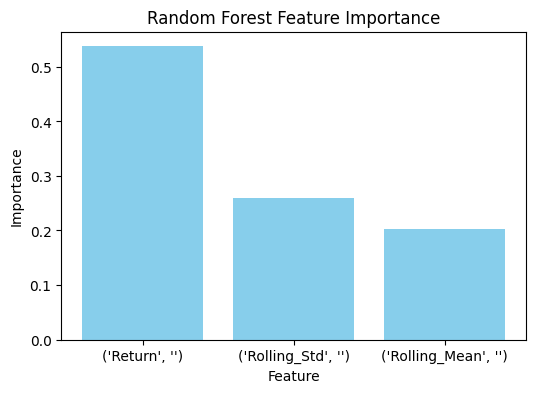

In [ ]:
# Ensure 'Feature' column is string type
rf_features['Feature'] = rf_features['Feature'].astype(str)

# Now plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(rf_features['Feature'], rf_features['Importance'], color='skyblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

Streamlit Dashboard

In [1]:
%%writefile market_shock_dashboard.py

import streamlit as st
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Page config
st.set_page_config(page_title="Market Shock Dashboard", layout="wide")

st.title("Market Shock Early Warning System")

# Sidebar inputs
st.sidebar.header("User Input")
ticker = st.sidebar.text_input("Stock Ticker", "RELIANCE.NS")
start_date = st.sidebar.date_input("Start Date", pd.to_datetime("2018-01-01"))
end_date = st.sidebar.date_input("End Date", pd.to_datetime("2024-01-01"))
window = st.sidebar.slider("Rolling Window", 3, 15, 5)
threshold = st.sidebar.slider("Z-score Threshold", 1.0, 3.0, 2.0)

# Load data
@st.cache_data
def load_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)
    return data

with st.spinner("Loading data..."):
    data = load_data(ticker, start_date, end_date)

# Preprocessing
data = data.dropna()

data['Return'] = data['Close'].pct_change()
data['Rolling_Mean'] = data['Return'].rolling(window).mean()
data['Rolling_Std'] = data['Return'].rolling(window).std()

data['Z_Score'] = (data['Return'] - data['Rolling_Mean']) / data['Rolling_Std']
data['Shock'] = (abs(data['Z_Score']) > threshold).astype(int)

data = data.dropna()

st.subheader("Data Preview")
st.write(data.tail())

# Plot rolling statistics
st.subheader("Rolling Statistics")

fig, ax = plt.subplots()
ax.plot(data.index, data['Rolling_Mean'], label="Rolling Mean")
ax.plot(data.index, data['Rolling_Std'], label="Rolling Std")

shock_points = data[data['Shock'] == 1]
ax.scatter(shock_points.index, shock_points['Return'], color='red', label="Shocks")

ax.legend()
st.pyplot(fig)

# Model Training
st.subheader("Model Training")

features = ['Return', 'Rolling_Mean', 'Rolling_Std']
X = data[features]
y = data['Shock']

if len(np.unique(y)) < 2:
    st.warning("Not enough shock events. Reduce threshold.")
else:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LogisticRegression(class_weight='balanced')
    model.fit(X_scaled, y)

    rf_model = RandomForestClassifier()
    rf_model.fit(X_scaled, y)

    st.success("Models trained successfully")

    # Prediction
    st.subheader("Next Day Prediction")

    latest = X.iloc[-1:]
    latest_scaled = scaler.transform(latest)

    lr_pred = model.predict(latest_scaled)[0]
    lr_prob = model.predict_proba(latest_scaled)[0][1]

    rf_pred = rf_model.predict(latest_scaled)[0]
    rf_prob = rf_model.predict_proba(latest_scaled)[0][1]

    st.write(f"Logistic Regression: {lr_prob:.2f} → {'Shock' if lr_pred==1 else 'Normal'}")
    st.write(f"Random Forest: {rf_prob:.2f} → {'Shock' if rf_pred==1 else 'Normal'}")

    # Feature importance
    st.subheader("Feature Importance")

    importance = pd.DataFrame({
        'Feature': features,
        'Importance': rf_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    st.bar_chart(importance.set_index('Feature'))

Writing market_shock_dashboard.py


In [2]:
!pip install streamlit yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 76.4 MB/s eta 0:00:00


In [3]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 5s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [ ]:
!streamlit run market_shock_dashboard.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸your url is: https://lazy-seals-design.loca.lt
